<a href="https://colab.research.google.com/github/AswinG2003/NLP-Parallel-Project/blob/Deep_Learning_model/NLP_Parallel_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries


In [3]:
# Install Required Packages (Run Once)


!pip install -q gensim wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.3 MB/s eta 0:00:00


In [77]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


# Machine Learning Utilities

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)


# Classical Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier


# Word2Vec

import gensim.downloader as api
from gensim.models import Word2Vec


# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Concatenate
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.preprocessing import label_binarize

In [6]:
# Download required NLTK resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Visualization settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


#Load Dataset


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# df_twitter = pd.read_csv("/content/drive/MyDrive/DATA/twitter_training[1].csv")
# df_twitter.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df_twitter= pd.read_csv("/content/drive/MyDrive/ICT AIML/Datasets/twitter/twitter_training.csv")

In [9]:
df_twitter.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [21]:
# Define meaningful column names
column_names = ["Tweet_ID", "Entity", "Sentiment", "Tweet"]

# # Load the dataset
df_twitter = pd.read_csv(
  "/content/drive/MyDrive/ICT AIML/Datasets/twitter/twitter_training.csv",
  names=column_names,
  header=None
 )

 # Display first five rows
df_twitter.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


#EDA


In [22]:
# Display basic information about the dataset

df_twitter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [23]:
print(f"Number of Rows    : {df_twitter.shape[0]}")
print(f"Number of Columns : {df_twitter.shape[1]}")

Number of Rows    : 74682
Number of Columns : 4


In [24]:
df_twitter.columns

Index(['Tweet_ID', 'Entity', 'Sentiment', 'Tweet'], dtype='object')

In [25]:
df_twitter.describe(include="all")

,Tweet_ID,Entity,Sentiment,Tweet
count,74682.000000,74682,74682,73996
unique,NaN,32,4,69491
top,NaN,Microsoft,Negative,"At the same time, despite the fact that there ..."
freq,NaN,2400,22542,172
mean,6432.586165,NaN,NaN,NaN
std,3740.427870,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6422.000000,NaN,NaN,NaN
75%,9601.000000,NaN,NaN,NaN


##Missing Value Analysis

In [26]:
# Check missing values

missing_values = df_twitter.isnull().sum()

missing_values

,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,686


In [27]:
# Missing value percentage

missing_percentage = (df_twitter.isnull().sum() / len(df_twitter)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage.round(2)
})

missing_df

,Missing Values,Percentage (%)
Tweet_ID,0,0.00
Entity,0,0.00
Sentiment,0,0.00
Tweet,686,0.92


##

## Duplicate Value Analysis

In [28]:
# Check duplicate rows

duplicates = df_twitter.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 2700


#NLP Preprocessing

## Handling Missing Values


In [29]:
# Remove rows with missing tweets
df_twitter.dropna(subset=["Tweet"], inplace=True)

print("Dataset Shape after removing missing values:", df_twitter.shape)

Dataset Shape after removing missing values: (73996, 4)


##Handling Duplicates

In [30]:
# Remove duplicate records
df_twitter.drop_duplicates(inplace=True)

print("Dataset Shape after removing duplicates:", df_twitter.shape)

Dataset Shape after removing duplicates: (71656, 4)


##Lowercasing

In [31]:
# Convert tweets to lowercase
df_twitter["Tweet"] = df_twitter["Tweet"].str.lower()

df_twitter[["Tweet"]].head()

,Tweet
0,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...
3,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...


## Punctuations

In [32]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df_twitter["Tweet"] = df_twitter["Tweet"].apply(remove_punctuation)

df_twitter[["Tweet"]].head()

,Tweet
0,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...


## Remove Numbers

In [33]:
import re

def remove_numbers(text):
    return re.sub(r"\d+", "", text)

df_twitter["Tweet"] = df_twitter["Tweet"].apply(remove_numbers)

df_twitter[["Tweet"]].head()

,Tweet
0,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...
4,im getting on borderlands and i will murder y...


## Remove URL's

In [34]:
def remove_urls(text):
    return re.sub(r"http\S+|www\S+", "", text)

df_twitter["Tweet"] = df_twitter["Tweet"].apply(remove_urls)

df_twitter[["Tweet"]].head()

,Tweet
0,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...
4,im getting on borderlands and i will murder y...


## Remove StopWords

In [35]:
import nltk
nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df_twitter["Tweet"] = df_twitter["Tweet"].apply(remove_stopwords)

df_twitter[["Tweet"]].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Tweet
0,im getting borderlands murder
1,coming borders kill
2,im getting borderlands kill
3,im coming borderlands murder
4,im getting borderlands murder


## Lemmatization

In [36]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

df_twitter["Tweet"] = df_twitter["Tweet"].apply(lemmatize_text)

df_twitter[["Tweet"]].head()

,Tweet
0,im getting borderland murder
1,coming border kill
2,im getting borderland kill
3,im coming borderland murder
4,im getting borderland murder


# Feature Engineering

## TF-IDF Vectorization

In [37]:
# Define input and target

X = df_twitter["Tweet"]
y = df_twitter["Sentiment"]

In [38]:
# Initialize TF-IDF Vectorizer

tfidf = TfidfVectorizer(max_features=5000)


In [39]:
# Transform text into TF-IDF features

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (71656, 5000)


## Word2Vec Embeddings

In [40]:
# Tokenize each tweet into words
tokenized_tweets = df_twitter["Tweet"].apply(word_tokenize)

# Display the first five tokenized tweets
tokenized_tweets.head()

,Tweet
0,"[im, getting, borderland, murder]"
1,"[coming, border, kill]"
2,"[im, getting, borderland, kill]"
3,"[im, coming, borderland, murder]"
4,"[im, getting, borderland, murder]"


In [41]:
# Train the Word2Vec model
word2vec_model = Word2Vec(
    sentences=tokenized_tweets,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [42]:
# Generate document embeddings by averaging word vectors

X_word2vec = []

for tokens in tokenized_tweets:
    word_vectors = [
        word2vec_model.wv[word]
        for word in tokens
        if word in word2vec_model.wv
    ]

    if len(word_vectors) > 0:
        X_word2vec.append(np.mean(word_vectors, axis=0))
    else:
        X_word2vec.append(np.zeros(word2vec_model.vector_size))

X_word2vec = np.array(X_word2vec)

In [43]:
print("Word2Vec Shape:", X_word2vec.shape)

Word2Vec Shape: (71656, 100)


In [ ]:
#The Word2Vec model converts each tweet into a dense numerical vector by averaging the embeddings of all words in the tweet. These embeddings capture semantic relationships between words and will be used for comparison with TF-IDF representations.

# Train-Test Split

In [44]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
X_train_w2v, X_test_w2v, _, _ = train_test_split(
    X_word2vec,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
print("TF-IDF Train :", X_train_tfidf.shape)
print("TF-IDF Test  :", X_test_tfidf.shape)

print("Word2Vec Train :", X_train_w2v.shape)
print("Word2Vec Test  :", X_test_w2v.shape)

TF-IDF Train : (57324, 5000)
TF-IDF Test  : (14332, 5000)
Word2Vec Train : (57324, 100)
Word2Vec Test  : (14332, 100)


# Model Building


## Logistic Regression

In [47]:
# Initialize Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [48]:
# Predict on the test set
y_pred_lr = lr_model.predict(X_test_tfidf)

In [49]:
# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.6801562936087078


In [50]:
# Classification Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

  Irrelevant       0.68      0.53      0.60      2507
    Negative       0.72      0.77      0.75      4340
     Neutral       0.63      0.64      0.63      3542
    Positive       0.68      0.71      0.69      3943

    accuracy                           0.68     14332
   macro avg       0.68      0.66      0.67     14332
weighted avg       0.68      0.68      0.68     14332



##### Inference: The Logistic Regression model achieved an overall accuracy of 68.02% on the test dataset. The model performed best in identifying Negative tweets, achieving the highest precision, recall, and F1-score. Performance on the Irrelevant class was comparatively lower, indicating that the model found it more difficult to distinguish irrelevant tweets from the other sentiment categories.

## SVM

In [51]:
# Initialize the Linear SVM model
svm_model = LinearSVC(random_state=42)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [52]:
# Initialize the Linear SVM model
svm_model = LinearSVC(random_state=42)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [53]:
# Predict the sentiments for the test data
y_pred_svm = svm_model.predict(X_test_tfidf)

In [54]:
# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", svm_accuracy)

Linear SVM Accuracy: 0.7002511861568518


In [55]:
# Display classification report
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

  Irrelevant       0.69      0.58      0.63      2507
    Negative       0.75      0.78      0.76      4340
     Neutral       0.65      0.67      0.66      3542
    Positive       0.70      0.72      0.71      3943

    accuracy                           0.70     14332
   macro avg       0.70      0.69      0.69     14332
weighted avg       0.70      0.70      0.70     14332



The Linear SVM model achieved an overall accuracy of 70.03%, outperforming Logistic Regression. It showed improved performance across most sentiment classes, particularly for the Negative and Positive categories, making it the better-performing classical machine learning model for this dataset.

# Deep Learning Model (Combination of TF-IDF and Word2Vec document embeddings)





In [70]:
# Build a Deep Learning model using a COMBINATION of TF-IDF and Word2Vec document embeddings

# Encode sentiment labels as integers for SparseCategoricalCrossentropy
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# --- Combine TF-IDF and Word2Vec features ---
# TF-IDF is high-dimensional and sparse (5000 dims); Word2Vec is dense (100 dims).
# Concatenating them directly would let TF-IDF dominate the input and would also
# be very memory-heavy once densified, so we first compress TF-IDF with
# TruncatedSVD (a form of LSA) down to a comparable dimensionality, then
# concatenate it with the Word2Vec document embeddings.

svd = TruncatedSVD(n_components=100, random_state=42)
X_tfidf_reduced = svd.fit_transform(X_tfidf)  # dense, shape (n_samples, 100)

print("TF-IDF (reduced) shape :", X_tfidf_reduced.shape)
print("Word2Vec shape         :", X_word2vec.shape)

# Concatenate the two dense feature sets into a single combined feature vector
X_combined = np.hstack([X_tfidf_reduced, X_word2vec])
print("Combined feature shape :", X_combined.shape)

# Use the combined features for the deep learning train/test split
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_combined,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

num_classes = len(label_encoder.classes_)
input_dim = X_train_dl.shape[1]

# Feed-forward neural network
dl_model = tf.keras.Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(num_classes, activation="softmax")
])

dl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dl_model.summary()

# Stop training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history = dl_model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


TF-IDF (reduced) shape : (71656, 100)
Word2Vec shape         : (71656, 100)
Combined feature shape : (71656, 200)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,244 (133.77 KB)

 Trainable params: 34,244 (133.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
717/717 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4904 - loss: 1.1775 - val_accuracy: 0.5248 - val_loss: 1.1096 - learning_rate: 0.0010
Epoch 2/100
717/717 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5148 - loss: 1.1270 - val_accuracy: 0.5330 - val_loss: 1.1029 - learning_rate: 0.0010
Epoch 3/100
717/717 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5250 - loss: 1.1043 - val_accuracy: 0.5412 - val_loss: 1.0723 - learning_rate: 0.0010
Epoch 4/100
717/717 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5336 - loss: 1.0861 - val_accuracy: 0.5437 - val_loss: 1.0626 - learning_rate: 0.0010
Epoch 5/100
717/717 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5383 - loss: 1.0732 - val_accuracy: 0.5509 - val_loss: 1.0507 - learning_rate: 0.0010
Epoch 6/100
717/717 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5440 - loss: 1.0644 - val_accuracy: 0.5509 - val_loss: 1.0417 - learning_rate: 0.0010
Epoch 7/100
717/717 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5485 - loss: 1.

## Plotting Accuracy and Loss

### Accuracy


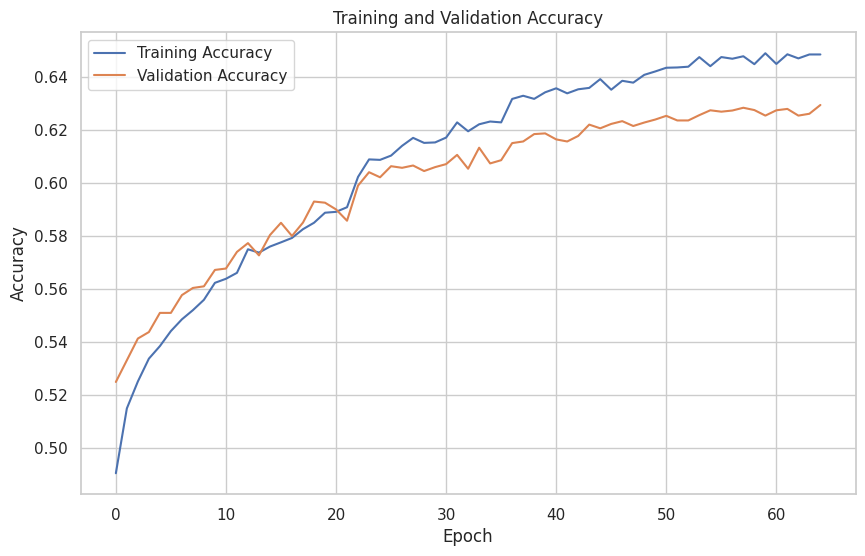

In [72]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

### Loss

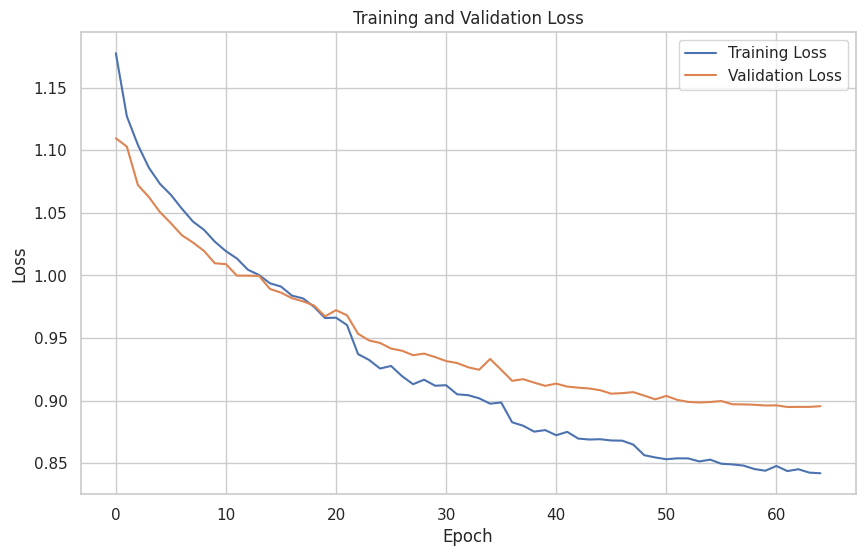

In [74]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

#Model Evalutation Deep learning

Deep Learning Test Loss     : 0.9044
Deep Learning Accuracy      : 0.6255
Deep Learning Precision     : 0.6236
Deep Learning Recall        : 0.6255
Deep Learning F1-score      : 0.6216

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.58      0.47      0.52      2507
    Negative       0.67      0.73      0.70      4340
     Neutral       0.62      0.54      0.57      3542
    Positive       0.60      0.69      0.64      3943

    accuracy                           0.63     14332
   macro avg       0.62      0.61      0.61     14332
weighted avg       0.62      0.63      0.62     14332



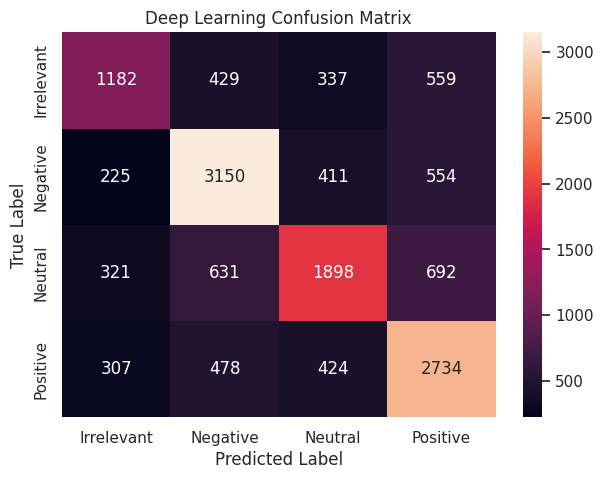

In [75]:
# Evaluate the Deep Learning model
dl_loss, dl_accuracy = dl_model.evaluate(X_test_dl, y_test_dl, verbose=0)

# Class predictions and probabilities
y_prob_dl = dl_model.predict(X_test_dl, verbose=0)
y_pred_dl = np.argmax(y_prob_dl, axis=1)

dl_precision = precision_score(y_test_dl, y_pred_dl, average="weighted")
dl_recall = recall_score(y_test_dl, y_pred_dl, average="weighted")
dl_f1 = f1_score(y_test_dl, y_pred_dl, average="weighted")

print(f"Deep Learning Test Loss     : {dl_loss:.4f}")
print(f"Deep Learning Accuracy      : {dl_accuracy:.4f}")
print(f"Deep Learning Precision     : {dl_precision:.4f}")
print(f"Deep Learning Recall        : {dl_recall:.4f}")
print(f"Deep Learning F1-score      : {dl_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_dl, y_pred_dl, target_names=label_encoder.classes_, zero_division=0))

# Confusion matrix
cm_dl = confusion_matrix(y_test_dl, y_pred_dl)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_dl, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Deep Learning Confusion Matrix")
plt.show()

# ROC Curve classical and Deep Learning

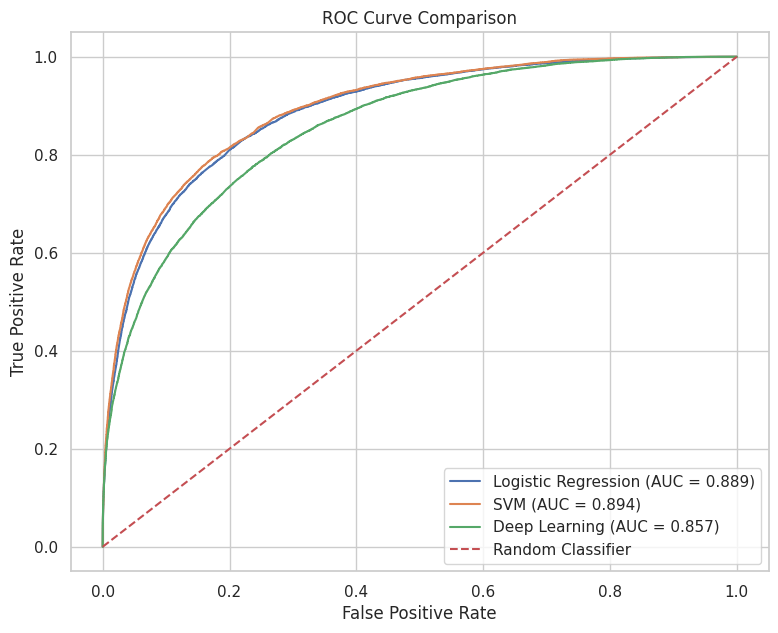

Logistic Regression ROC-AUC : 0.8891
SVM ROC-AUC                 : 0.8937
Deep Learning ROC-AUC       : 0.8574


In [78]:
classes = label_encoder.classes_
y_test_common = label_encoder.transform(y_test)
y_test_bin = label_binarize(y_test_common, classes=np.arange(len(classes)))

y_prob_lr = lr_model.predict_proba(X_test_tfidf)
y_score_svm = svm_model.decision_function(X_test_tfidf)
y_prob_dl_common = y_prob_dl

plt.figure(figsize=(9, 7))
fpr_lr, tpr_lr, _ = roc_curve(y_test_bin.ravel(), y_prob_lr.ravel())
fpr_svm, tpr_svm, _ = roc_curve(y_test_bin.ravel(), y_score_svm.ravel())
fpr_dl, tpr_dl, _ = roc_curve(y_test_bin.ravel(), y_prob_dl_common.ravel())

auc_lr = auc(fpr_lr, tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)
auc_dl = auc(fpr_dl, tpr_dl)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_dl, tpr_dl, label=f"Deep Learning (AUC = {auc_dl:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

print(f"Logistic Regression ROC-AUC : {auc_lr:.4f}")
print(f"SVM ROC-AUC                 : {auc_svm:.4f}")
print(f"Deep Learning ROC-AUC       : {auc_dl:.4f}")

# Precision Recall Curve

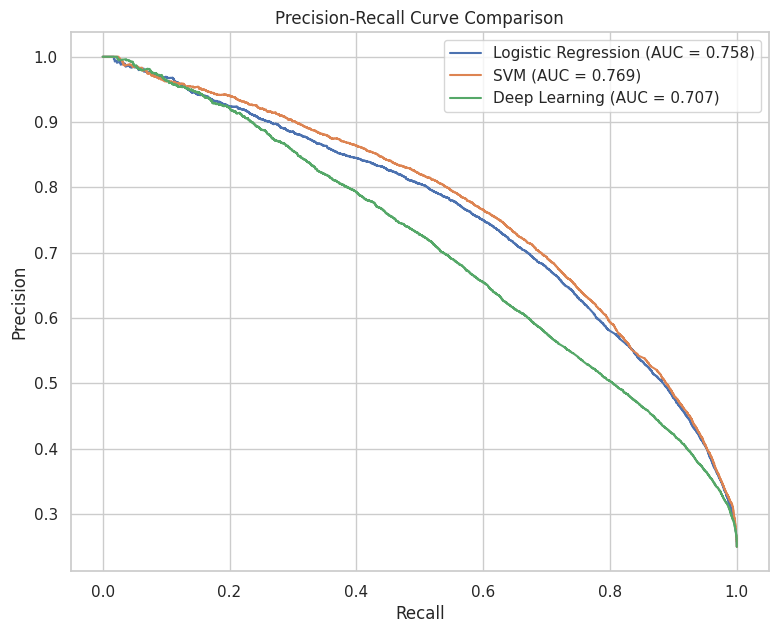

Logistic Regression PR-AUC : 0.7576
SVM PR-AUC                 : 0.7691
Deep Learning PR-AUC       : 0.7072


In [81]:
plt.figure(figsize=(9, 7))
precision_lr, recall_lr, _ = precision_recall_curve(y_test_bin.ravel(), y_prob_lr.ravel())
precision_svm, recall_svm, _ = precision_recall_curve(y_test_bin.ravel(), y_score_svm.ravel())
precision_dl, recall_dl, _ = precision_recall_curve(y_test_bin.ravel(), y_prob_dl_common.ravel())

pr_auc_lr = auc(recall_lr, precision_lr)
pr_auc_svm = auc(recall_svm, precision_svm)
pr_auc_dl = auc(recall_dl, precision_dl)

plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (AUC = {pr_auc_lr:.3f})")
plt.plot(recall_svm, precision_svm, label=f"SVM (AUC = {pr_auc_svm:.3f})")
plt.plot(recall_dl, precision_dl, label=f"Deep Learning (AUC = {pr_auc_dl:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

print(f"Logistic Regression PR-AUC : {pr_auc_lr:.4f}")
print(f"SVM PR-AUC                 : {pr_auc_svm:.4f}")
print(f"Deep Learning PR-AUC       : {pr_auc_dl:.4f}")

# Final Model Comparison



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Linear SVM,0.7003,0.6996,0.7003,0.6989,0.8937,0.7691
1,Logistic Regression,0.6802,0.6794,0.6802,0.6779,0.8891,0.7576
2,Deep Learning,0.6255,0.6236,0.6255,0.6216,0.8574,0.7072


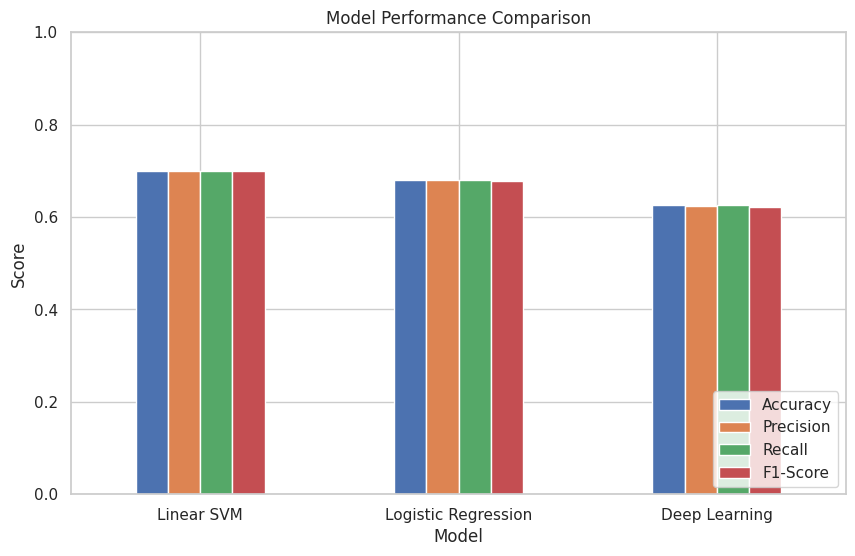

In [83]:
lr_precision = precision_score(y_test, y_pred_lr, average="weighted")
lr_recall = recall_score(y_test, y_pred_lr, average="weighted")
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")

svm_precision = precision_score(y_test, y_pred_svm, average="weighted")
svm_recall = recall_score(y_test, y_pred_svm, average="weighted")
svm_f1 = f1_score(y_test, y_pred_svm, average="weighted")

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "Deep Learning"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_svm), dl_accuracy],
    "Precision": [lr_precision, svm_precision, dl_precision],
    "Recall": [lr_recall, svm_recall, dl_recall],
    "F1-Score": [lr_f1, svm_f1, dl_f1],
    "ROC-AUC": [auc_lr, auc_svm, auc_dl],
    "PR-AUC": [pr_auc_lr, pr_auc_svm, pr_auc_dl]
})

comparison_df = comparison_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(comparison_df.round(4))

comparison_plot = comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]]
comparison_plot.plot(kind="bar", figsize=(10, 6))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

# Conclusion

In [84]:
best_model = comparison_df.iloc[0]["Model"]
best_f1 = comparison_df.iloc[0]["F1-Score"]

print(f"The comparison shows that {best_model} achieved the highest weighted F1-score ({best_f1:.4f}) among the evaluated models.")
print("Logistic Regression and Linear SVM were trained using TF-IDF features, while the Deep Learning model used a combined 200-dimensional feature vector (100-dim SVD-reduced TF-IDF + 100-dim Word2Vec document embeddings).")
print("The Deep Learning model used a feed-forward neural network with two hidden layers, ReLU activation, dropout regularization, early stopping, and learning-rate reduction.")
print("ROC-AUC and Precision-Recall AUC were also compared to provide a broader evaluation beyond accuracy.")

The comparison shows that Linear SVM achieved the highest weighted F1-score (0.6989) among the evaluated models.
Logistic Regression and Linear SVM were trained using TF-IDF features, while the Deep Learning model used a combined 200-dimensional feature vector (100-dim SVD-reduced TF-IDF + 100-dim Word2Vec document embeddings).
The Deep Learning model used a feed-forward neural network with two hidden layers, ReLU activation, dropout regularization, early stopping, and learning-rate reduction.
ROC-AUC and Precision-Recall AUC were also compared to provide a broader evaluation beyond accuracy.
